## Overview

The PACE Level-3 (gridded) OCI (ocean color instrument) data is available on an NASA EarthData. Search using the instrument filter "OCI" and processing level filter "Gridded Observations" <https://search.earthdata.nasa.gov/search?fi=OCI&fl=3%2B-%2BGridded%2BObservations> and you will see 45+ data collections. In this tutorial, we will look at the Chlorophyll (CHL) product.

The short name is "PACE_OCI_L3M_BGC". Note it changed to "PACE_OCI_L3M_BGC" from "PACE_OCI_L3M_CHL".

The Copernicus Globcolour product is this:
https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/services

The Globcolour gap-free products are here
https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L4_MY_009_104/services
They have CHL and KD (transparency) daily gap-free products.

Copernicus L3 OLCI daily product is made from 2 satellites, Sentinel-3A and Sentinel-3B OLCI observations, mapped onto a regular 4 km grid. It has 11 RRS bands. This reduces swath stripes (2 satellites). Reprojection from native ~300 m pixels to a 4 km grid might further reduce the visual swath structure.

The Copernicus L3 multi-sensor daily product is made from many satellites so will not show swath stripes. It has 5 RRS bands.

### Prerequisites

You need to have an EarthData Login username and password. Go here to get one <https://urs.earthdata.nasa.gov/>

I assume you have a `.netrc` file at `~` (home). `~/.netrc` should look just like this with your username and password. Create that file if needed. You don't need to create it if you don't have this file. The `earthaccess.login(persist=True)` line will ask for your username and password and create the `.netrc` file for you.

```
machine urs.earthdata.nasa.gov
        login yourusername
        password yourpassword
```

#### For those not working in the JupyterHub

Uncomment this and run the cell:


In [1]:
# pip install earthaccess

### Create a NASA EDL authenticated session

Authenticate with `earthaccess.login()`.Authenticate with `earthaccess.login()`. You will need your EarthData Login username and password for this step. Get one here [https://urs.earthdata.nasa.gov/](https://urs.earthdata.nasa.gov/).

In [1]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

## Daily data

We need the data links that have 0.1 deg and DAY in the file name.

In [108]:
import earthaccess
results_day = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_BGC",
    temporal = ("2024-03-01", "2024-03-31"),
    granule_name="*.DAY.*.4km.*"
)
len(results_day)

23

In [21]:
results_day[0]

Collection: {'Version': '3.2', 'ShortName': 'PACE_OCI_L3M_BGC'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'EastBoundingCoordinate': 180, 'SouthBoundingCoordinate': -90, 'NorthBoundingCoordinate': 90}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-03-05T00:00:00Z', 'EndingDateTime': '2024-03-05T23:59:59Z'}}
Size(MB): 9.342856407165527
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240305.L3m.DAY.BGC.V3_2.0p1deg.nc']

In [109]:
# let's load the data
fileset = earthaccess.open(results_day)

QUEUEING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/23 [00:00<?, ?it/s]

In [110]:
# We need to create the dates from the fileset since the original files do not have the time
import pandas as pd
import re

# Extract dates from file paths
date_pattern = re.compile(r"PACE_OCI\.(\d{8})")

dates = []
for f in fileset:
    match = date_pattern.search(f.path)
    if not match:
        raise ValueError(f"Could not extract date from: {f.path}")
    date_str = match.group(1)
    dates.append(pd.to_datetime(date_str, format="%Y%m%d"))

# Sanity check
if len(dates) != len(fileset):
    raise ValueError(f"Mismatch: found {len(dates)} dates for {len(fileset)} files")

dates[0:3]

[Timestamp('2024-03-05 00:00:00'),
 Timestamp('2024-03-06 00:00:00'),
 Timestamp('2024-03-07 00:00:00')]

In [111]:
import xarray as xr
pace_ds = xr.open_mfdataset(
    fileset,
    combine="nested",
    concat_dim="time"
)

# Overwrite with correct dates
pace_ds = pace_ds.assign_coords(time=("time", dates))

In [102]:
pace_ds

<xarray.Dataset> Size: 19GB
Dimensions:       (time: 31, lat: 4320, lon: 8640)
Coordinates:
  * time          (time) datetime64[ns] 248B 2024-07-01 ... 2024-07-31
  * lat           (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon           (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    poc           (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    pic           (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    chlor_a       (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    carbon_phyto  (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
Attributes: (12/55)
    product_name:                      PACE_OCI.20240701.L3m.DAY.BGC.V3_2.4km.nc
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    id:                                L3/PACE_OCI.20240701.L3m.DAY.BGC.V3_2....
    history:                           /sdps/sdpsoper/Science/OCSSW/V2026.2/b...
    processing_version:                3.2
    identifier_product_doi_authority:  https://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/OC_BGC/3.2

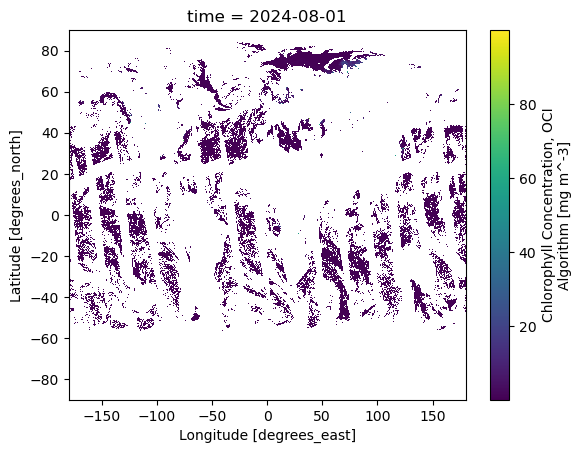

In [19]:
pace_ds["chlor_a"].isel(time=0).plot();

In [20]:
import matplotlib.pyplot as plt
import gc
plt.show()
plt.clf()       # Clear the current figure
plt.close()     # Close the figure window
gc.collect()    # Ask Python to free up memory


75779

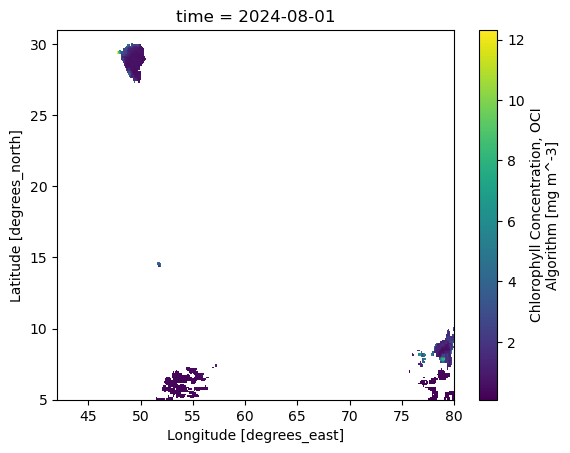

In [49]:
# let's look at the Arabian Sea
# Define bounding box
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80

pace_ds["chlor_a"].isel(time=0).sel(lat = slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).plot();

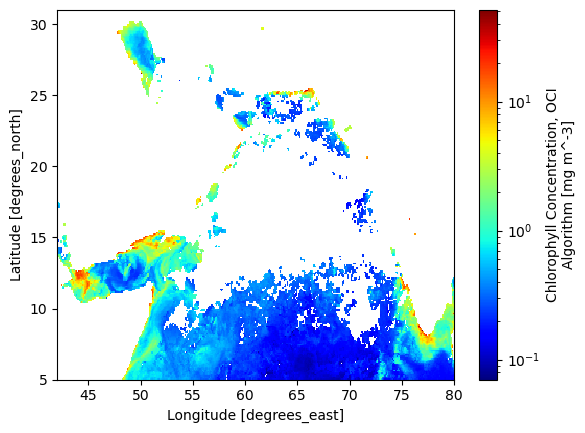

In [22]:
# Let's put on log scale and the jet colormap
import matplotlib.colors as mcolors
ds_mean = ds["chlor_a"].mean(dim="time");
ds_mean.sel(lat = slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).plot(
    norm=mcolors.LogNorm(),
    cmap="jet"
);

## Plot individual days to see when it is cloudy

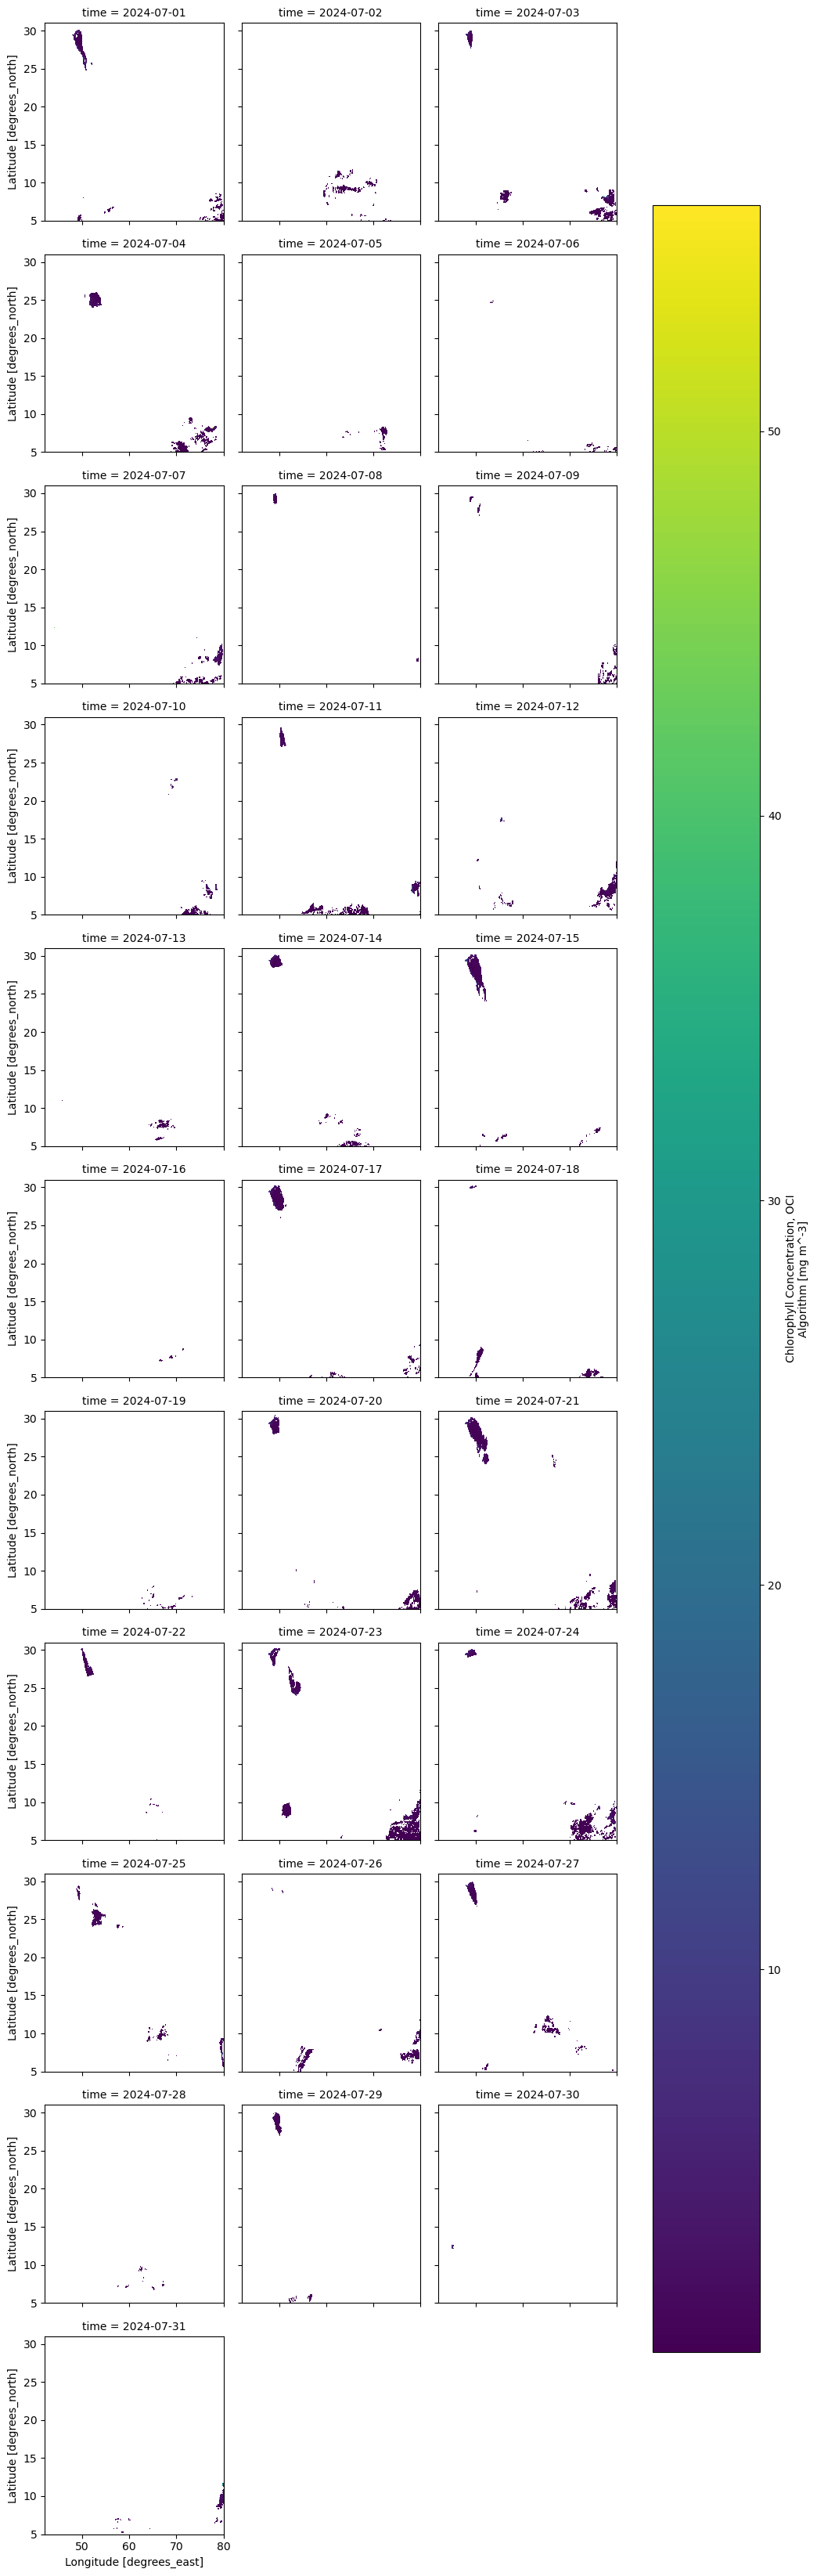

In [14]:
# We can plot over the days to see when it was cloudy
ds['chlor_a'].sel(lat = slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).plot(x='lon', y='lat', col="time", col_wrap=3);

## References

* [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io)
* [xarray user guide](https://docs.xarray.dev/en/stable/user-guide/index.html)

In [92]:
# Get a whole year
import copernicusmarine

ds_2024 = copernicusmarine.open_dataset(
    dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
    start_datetime="2024-01-01",
    end_datetime="2024-12-31",
    minimum_longitude=42,
    maximum_longitude=80,
    minimum_latitude=5,
    maximum_latitude=31,
)

ds_2024.nbytes / 1e9

INFO - 2026-07-23T21:48:56Z - Selected dataset version: "202603"
INFO - 2026-07-23T21:48:56Z - Selected dataset part: "default"


25.20264024

In [93]:
ds_2024

<xarray.Dataset> Size: 25GB
Dimensions:              (time: 366, latitude: 624, longitude: 912)
Coordinates:
  * time                 (time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude             (latitude) float32 2kB 5.021 5.062 ... 30.94 30.98
  * longitude            (longitude) float32 4kB 42.02 42.06 ... 79.94 79.98
Data variables: (12/21)
    CHL                  (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    CHL_uncertainty      (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    DIATO                (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    DIATO_uncertainty    (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    DINO                 (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    DINO_uncertainty     (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    ...                   ...
    PICO_uncertainty     (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    PROCHLO              (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    PROCHLO_uncertainty  (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    PROKAR               (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    PROKAR_uncertainty   (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    flags                (time, latitude, longitude) int8 208MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
Attributes:
    comment:      average
    title:        cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D
    institution:  ACRI
    references:   http://www.globcolour.info GlobColour has been originally f...
    source:       surface observation
    contact:      servicedesk.cmems@acri-st.fr
    history:      Created using software developed at ACRI-ST
    Conventions:  CF-1.8, ACDD-1.3

In [95]:
pace_ds

<xarray.Dataset> Size: 19GB
Dimensions:       (time: 31, lat: 4320, lon: 8640)
Coordinates:
  * time          (time) datetime64[ns] 248B 2024-07-01 ... 2024-07-31
  * lat           (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon           (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    poc           (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    pic           (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    chlor_a       (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    carbon_phyto  (time, lat, lon) float32 5GB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
Attributes: (12/55)
    product_name:                      PACE_OCI.20240701.L3m.DAY.BGC.V3_2.4km.nc
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    id:                                L3/PACE_OCI.20240701.L3m.DAY.BGC.V3_2....
    history:                           /sdps/sdpsoper/Science/OCSSW/V2026.2/b...
    processing_version:                3.2
    identifier_product_doi_authority:  https://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/OC_BGC/3.2

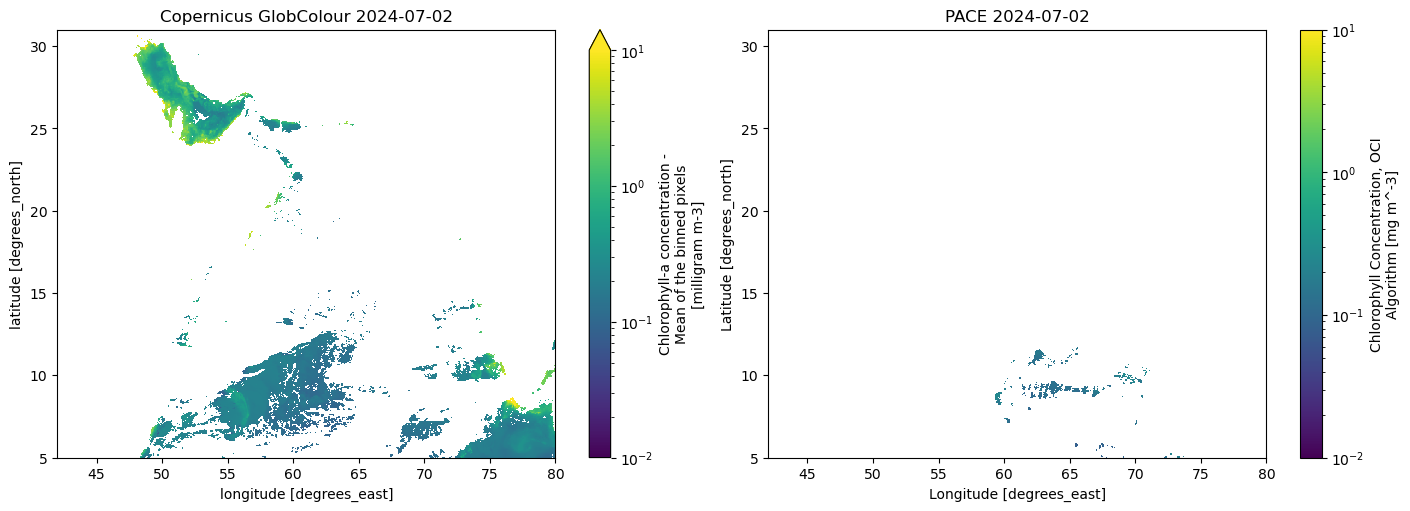

In [105]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Arabian Sea bounding box
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80
date = "2024-07-02"

var = "CHL"

globcolour = ds_2024[var].sel(time=date).sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max),
)

pace = pace_ds["chlor_a"].sel(time=date).sel(
    lat=slice(lat_max, lat_min),  # PACE latitude is descending
    lon=slice(lon_min, lon_max),
)

# Shared logarithmic color scale
norm = LogNorm(vmin=0.01, vmax=10)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    constrained_layout=True,
)

globcolour.plot(
    ax=axes[0],
    norm=norm,
    cmap="viridis",
)
axes[0].set_title(f"Copernicus GlobColour {date}")

pace.plot(
    ax=axes[1],
    norm=norm,
    cmap="viridis",
)
axes[1].set_title(f"PACE {date}")

plt.show()

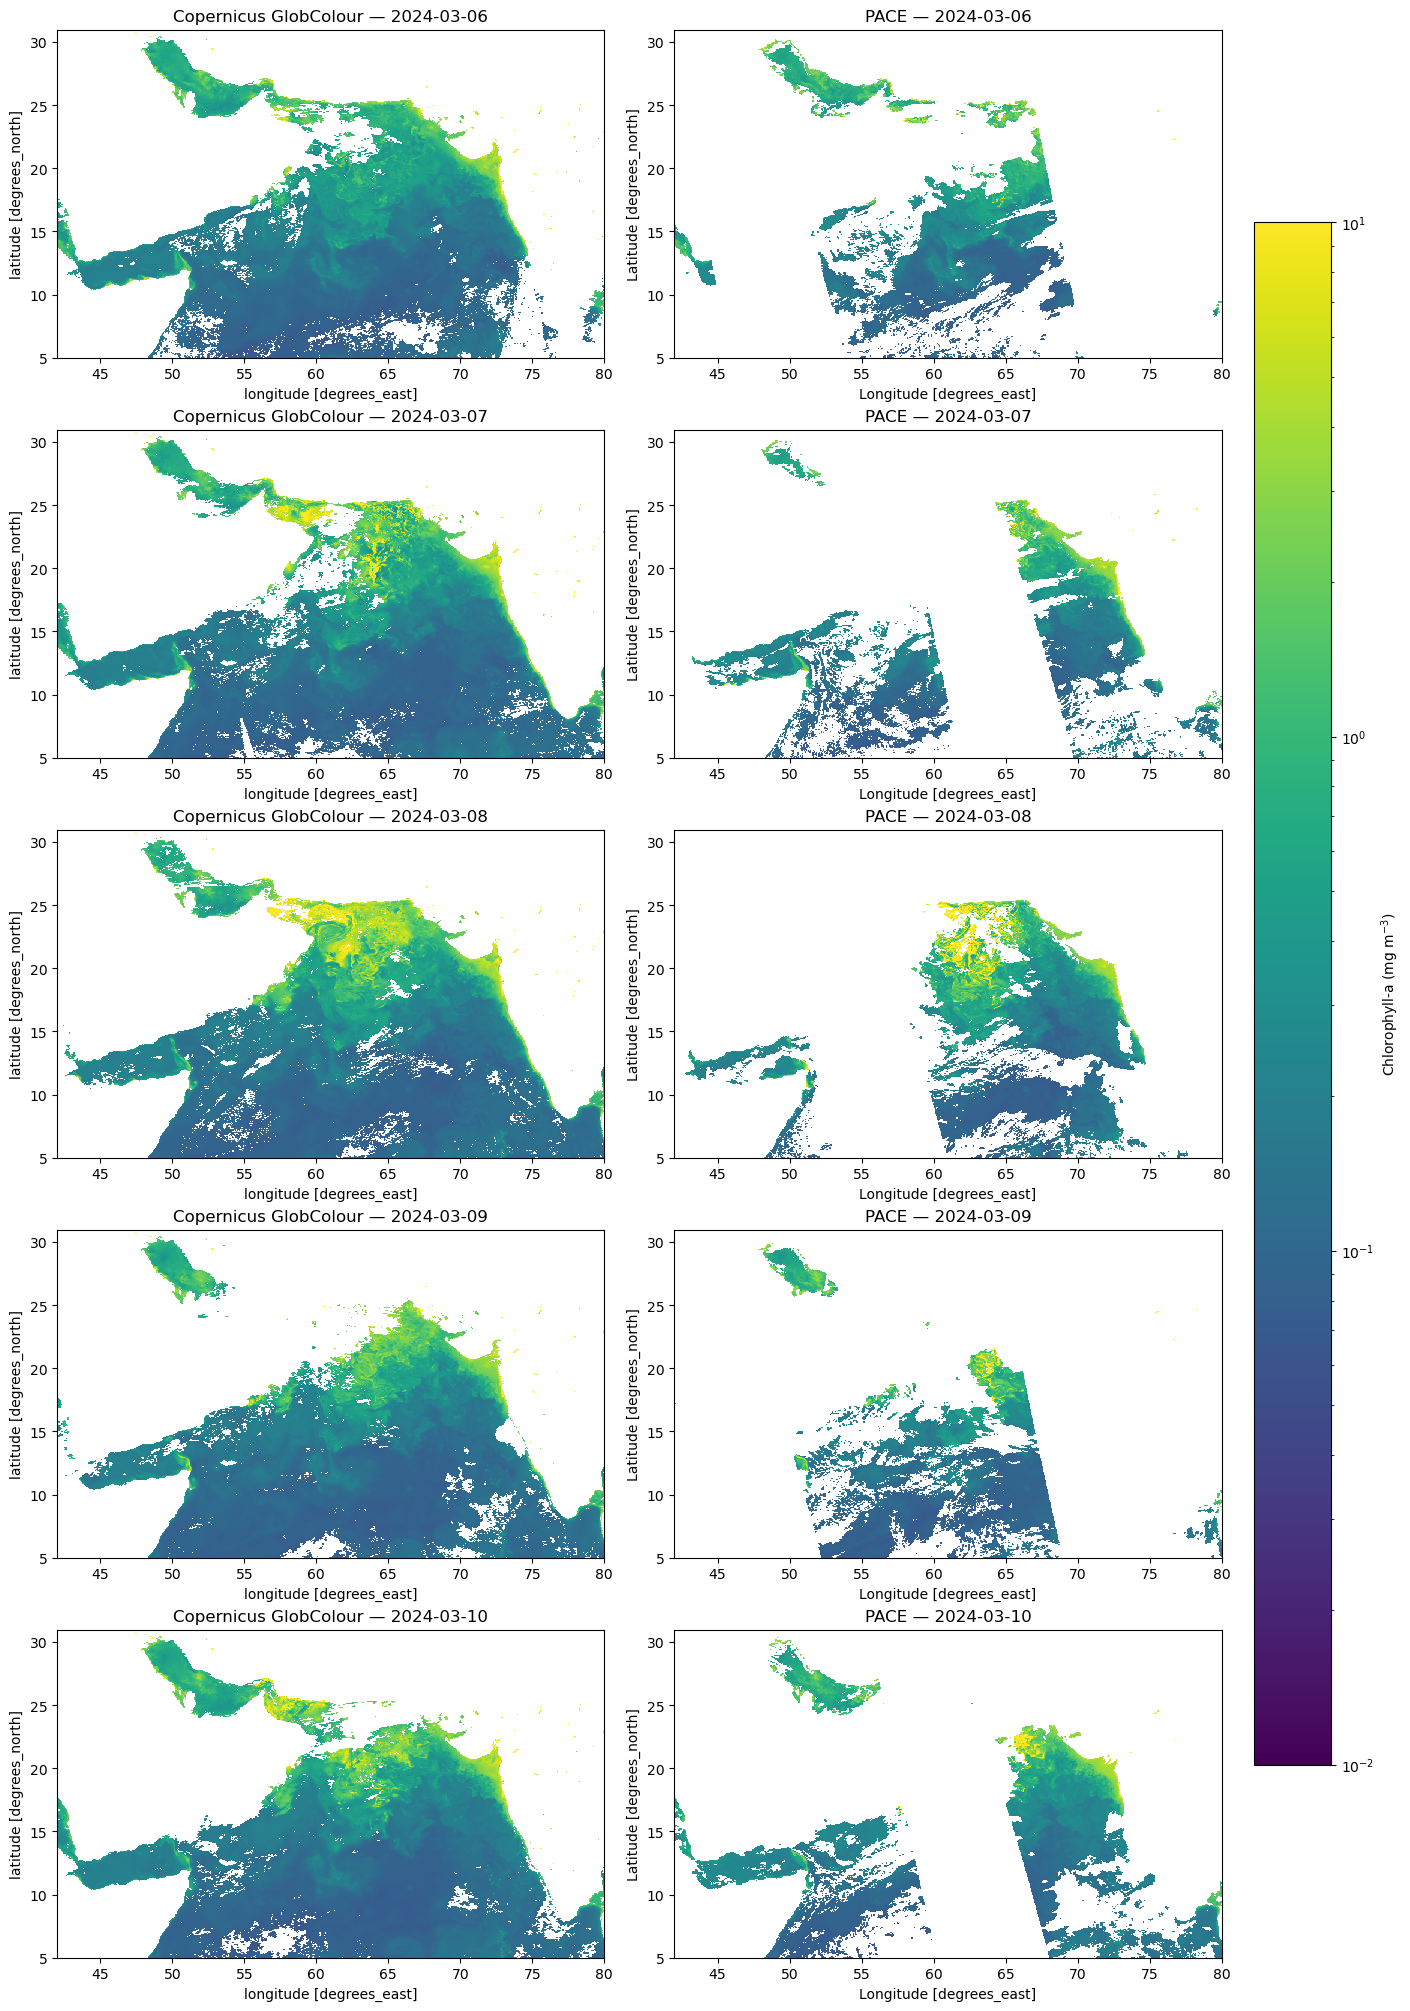

In [112]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm

# Arabian Sea bounding box
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80

start_date = "2024-03-06"
n = 5

var = "CHL"
dates = pd.date_range(start_date, periods=n, freq="D")

# Shared logarithmic color scale
norm = LogNorm(vmin=0.01, vmax=10)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(14, 4 * n),
    constrained_layout=True,
    squeeze=False,
)

for row, date in enumerate(dates):
    date_string = date.strftime("%Y-%m-%d")

    globcolour = ds_2024[var].sel(time=date_string).sel(
        latitude=slice(lat_min, lat_max),
        longitude=slice(lon_min, lon_max),
    )

    pace = pace_ds["chlor_a"].sel(time=date_string).sel(
        lat=slice(lat_max, lat_min),  # PACE latitude is descending
        lon=slice(lon_min, lon_max),
    )

    im = globcolour.plot(
        ax=axes[row, 0],
        norm=norm,
        cmap="viridis",
        add_colorbar=False,
    )
    axes[row, 0].set_title(f"Copernicus GlobColour — {date_string}")

    pace.plot(
        ax=axes[row, 1],
        norm=norm,
        cmap="viridis",
        add_colorbar=False,
    )
    axes[row, 1].set_title(f"PACE — {date_string}")

# One shared colorbar for all panels
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.8,
    pad=0.02,
)
cbar.set_label("Chlorophyll-a (mg m$^{-3}$)")

plt.show()

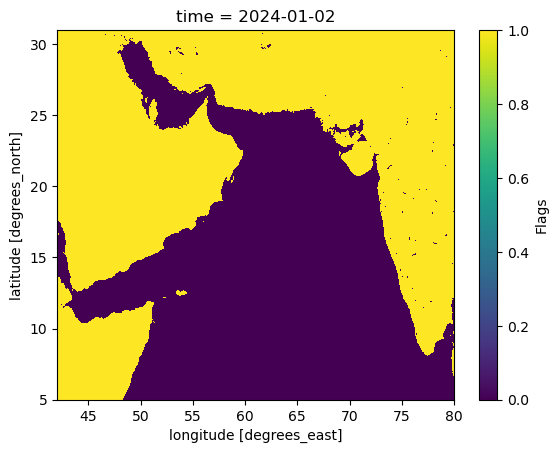

In [91]:
# land is 1
ds_2024.flags.isel(time=1).plot()

## Gapfree

In [117]:
product = "cmems_obs-oc_glo_bgc-plankton_my_l4-gapfree-multi-4km_P1D"
product = "cmems_obs-oc_glo_bgc-reflectance_my_l3-olci-4km_P1D"
product = "cmems_obs-oc_glo_bgc-reflectance_my_l3-multi-4km_P1D"
# Get a whole year
import copernicusmarine

ds = copernicusmarine.open_dataset(
    dataset_id=product,
    start_datetime="2024-01-01",
    end_datetime="2024-12-31",
    minimum_longitude=42,
    maximum_longitude=80,
    minimum_latitude=5,
    maximum_latitude=31,
)
ds

INFO - 2026-07-23T22:35:15Z - Selected dataset version: "202603"
INFO - 2026-07-23T22:35:15Z - Selected dataset part: "default"


<xarray.Dataset> Size: 13GB
Dimensions:             (time: 366, latitude: 624, longitude: 912)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude            (latitude) float32 2kB 5.021 5.062 5.104 ... 30.94 30.98
  * longitude           (longitude) float32 4kB 42.02 42.06 42.1 ... 79.94 79.98
Data variables:
    RRS412              (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS412_uncertainty  (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS443              (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS443_uncertainty  (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS490              (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS490_uncertainty  (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS555              (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS555_uncertainty  (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS670              (time, latitude, longitude) float32 833MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    RRS670_uncertainty  (time, latitude, longitude) float64 2GB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
    flags               (time, latitude, longitude) int8 208MB dask.array<chunksize=(50, 624, 912), meta=np.ndarray>
Attributes:
    comment:      average
    title:        cmems_obs-oc_glo_bgc-reflectance_my_l3-multi-4km_P1D
    institution:  ACRI
    references:   http://www.globcolour.info GlobColour has been originally f...
    source:       surface observation
    contact:      servicedesk.cmems@acri-st.fr
    history:      Created using software developed at ACRI-ST
    Conventions:  CF-1.8, ACDD-1.3

In [114]:
!copernicusmarine get \
  --dataset-id cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D \
  --dataset-version 202603 \
  --filter "*20240702*.nc" \
  --create-file-list globcolour_files.txt

INFO - 2026-07-23T22:24:17Z - Selected dataset version: "202603"
INFO - 2026-07-23T22:24:17Z - Selected dataset part: "default"
INFO - 2026-07-23T22:24:18Z - Listing files on remote server...
11it [00:05,  2.17it/s]
{
  "number_of_files_to_download": 0,
  "status": "002",
  "message": "The request created a file list and then stopped."
}


In [115]:
from pathlib import Path

path = Path("globcolour_files.txt")

print(path.exists())
print(path.read_text()[:2000])

True
s3://mdl-native-16/native/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D_202603/2024/07/20240702_cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D.nc



In [124]:
from pathlib import Path
import os
import xarray as xr
import s3fs

file_list = Path("globcolour_files.txt")
assert file_list.exists(), "globcolour_files.txt not found"

# Step 1: get one URL from file list
with file_list.open() as f:
    first_url = next(line.strip() for line in f if line.strip())

print("Testing URL:", first_url)

Testing URL: s3://mdl-native-16/native/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D_202603/2024/07/20240702_cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D.nc


In [126]:
# Step 2: helper to test open via s3fs + xarray
def try_open_s3_url(url, storage_options=None, engine="h5netcdf"):
    storage_options = storage_options or {}
    fs = s3fs.S3FileSystem(**storage_options)
    # url like s3://bucket/key...
    path = url.replace("s3://", "", 1)

    try:
        info = fs.info(path)
        print("✅ fs.info success")
        print("   size:", info.get("Size") or info.get("size"))
    except Exception as e:
        print("❌ fs.info failed:", repr(e))
        return None

    try:
        # open through file-like object; robust for many netcdf-on-s3 cases
        with fs.open(path, "rb") as fobj:
            ds = xr.open_dataset(fobj, engine=engine)
            print("✅ xarray open_dataset success")
            print(ds)
            return ds
    except Exception as e:
        print(f"❌ xarray open_dataset failed (engine={engine}):", repr(e))
        return None

# Step 3A: try anonymous first
ds = try_open_s3_url(
    first_url,
    storage_options={"anon": True},
    engine="h5netcdf",
)

if ds is None:
    # optional second engine
    ds = try_open_s3_url(
        first_url,
        storage_options={"anon": True},
        engine="netcdf4",
    )

❌ fs.info failed: FileNotFoundError('The specified bucket does not exist')
❌ fs.info failed: FileNotFoundError('The specified bucket does not exist')


## Compare Rrs

In [120]:
import copernicusmarine
import matplotlib.pyplot as plt
import numpy as np

date = "2024-08-01"

# Indian Ocean / Arabian Sea region
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80

products = {
    "OLCI": "cmems_obs-oc_glo_bgc-reflectance_my_l3-olci-4km_P1D",
    "Multi-sensor": "cmems_obs-oc_glo_bgc-reflectance_my_l3-multi-4km_P1D",
}

datasets = {
    name: copernicusmarine.open_dataset(
        dataset_id=product,
        start_datetime=date,
        end_datetime=date,
        minimum_longitude=lon_min,
        maximum_longitude=lon_max,
        minimum_latitude=lat_min,
        maximum_latitude=lat_max,
    )
    for name, product in products.items()
}


INFO - 2026-07-23T22:38:30Z - Selected dataset version: "202207"
INFO - 2026-07-23T22:38:30Z - Selected dataset part: "default"
INFO - 2026-07-23T22:38:42Z - Selected dataset version: "202603"
INFO - 2026-07-23T22:38:42Z - Selected dataset part: "default"


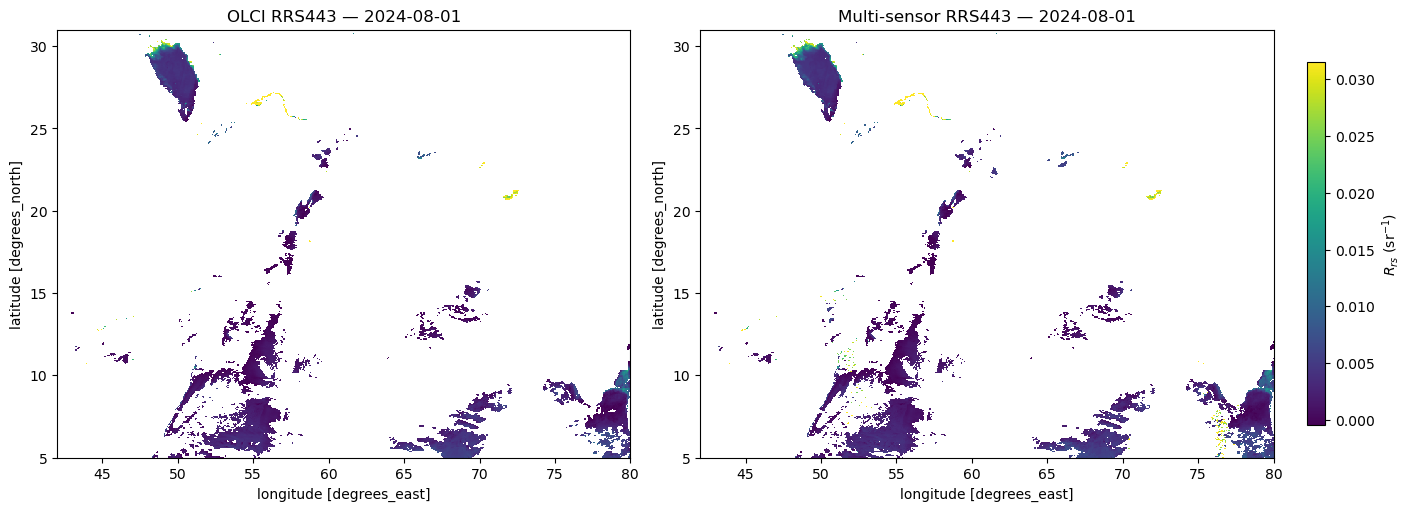

In [121]:
rrs_var = "RRS443"  # adjust capitalization/name based on output above

olci = datasets["OLCI"][rrs_var].sel(time=date).squeeze().load()
multi = datasets["Multi-sensor"][rrs_var].sel(time=date).squeeze().load()

# One shared color scale, excluding extreme outliers
combined = np.concatenate([
    olci.values[np.isfinite(olci.values)],
    multi.values[np.isfinite(multi.values)],
])

vmin, vmax = np.nanpercentile(combined, [1, 99])

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    constrained_layout=True,
)

im = olci.plot(
    ax=axes[0],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
)
axes[0].set_title(f"OLCI {rrs_var} — {date}")

multi.plot(
    ax=axes[1],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
)
axes[1].set_title(f"Multi-sensor {rrs_var} — {date}")

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02,
)
cbar.set_label(r"$R_{rs}$ (sr$^{-1}$)")

plt.show()

In [122]:
# Get a whole year
import copernicusmarine

ds_2024 = copernicusmarine.open_dataset(
    dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
    start_datetime="2024-01-01",
    end_datetime="2024-12-31",
)

INFO - 2026-07-23T22:46:54Z - Selected dataset version: "202603"
INFO - 2026-07-23T22:46:54Z - Selected dataset part: "default"


In [123]:
ds_2024.nbytes / 1e9

1652.966147568

In [127]:
copernicusmarine.__version__

'2.2.5'

In [128]:
!curl -I "https://s3.waw3-1.cloudferro.com/mdl-native-16/native/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D_202603/2024/07/20240702_cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D.nc?x-cop-client=copernicus-marine-toolbox&x-cop-client-version=2.2.5&x-cop-user=eeholmes"

HTTP/1.1 200 OK
server: nginx/1.27.2
date: Thu, 23 Jul 2026 23:19:25 GMT
content-type: binary/octet-stream
content-length: 265748086
accept-ranges: bytes
last-modified: Mon, 09 Mar 2026 23:22:05 GMT
x-rgw-object-type: Normal
etag: "33b2c0d16f05c91c7b00f01478402e49-32"
x-amz-request-id: tx00000ea773c584a5c3c12-006a62a17d-3fb6ff3ff-default



In [129]:
!curl -v -r 0-1023 -o /tmp/test.nc.part \
  "https://s3.waw3-1.cloudferro.com/mdl-native-16/native/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D_202603/2024/07/20240702_cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D.nc?x-cop-client=copernicus-marine-toolbox&x-cop-client-version=2.2.5&x-cop-user=eeholmes"


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0* Host s3.waw3-1.cloudferro.com:443 was resolved.
* IPv6: (none)
* IPv4: 45.92.242.74
*   Trying 45.92.242.74:443...
* ALPN: curl offers h2,http/1.1
} [5 bytes data]
* TLSv1.3 (OUT), TLS handshake, Client hello (1):
} [1568 bytes data]
* SSL Trust Anchors:
*   CAfile: /srv/conda/envs/notebook/ssl/cacert.pem
{ [5 bytes data]
* TLSv1.3 (IN), TLS handshake, Server hello (2):
{ [122 bytes data]
* TLSv1.3 (IN), TLS change cipher, Change cipher spec (1):
{ [1 bytes data]
* TLSv1.3 (IN), TLS handshake, Encrypted Extensions (8):
{ [10 bytes data]
* TLSv1.3 (IN), TLS handshake, Certificate (11):
{ [4122 bytes data]
* TLSv1.3 (IN), TLS handshake, CERT verify (15):
{ [264 bytes data]
* TLSv1.3 (IN), TLS handshake, Finished (20):
{ [52 bytes data]
* TLSv1.3 (OUT), TLS 